In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# Valores de las variables 
Nind = 100 
Lind = 20 
Pc = 0.7
Pm = 1.0/15.0
Maxgen = 1000 
Nvar = 1
rango = np.array([[0.0],[0.875]]) 

In [19]:
def creapob(Nind, Lind): 
    return np.random.randint(0,2, size=(Nind, Lind)) 

In [26]:
def decodifica(genotipo, rango):      
    rango = np.atleast_2d(rango)
    if rango.shape[0] != 2:
        rango = rango.T 

    Nvar = rango.shape[1]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)
    fenotipo = np.zeros((Nind, Nvar))

    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i, j] = np.sum(potencias * genotipo[i, (j * Lvar):(j * Lvar + Lvar)])

    for i in range(Nvar):
        fenotipo[:, i] = (rango[0, i] +
                          ((rango[1, i] - rango[0, i]) / (2 ** Lvar - 1)) * fenotipo[:, i])
    return fenotipo

In [7]:
def objfun(fenotipo): 
    Nind, Nvar = fenotipo.shape
    objv = np.zeros((Nind, 1))
    for i in range(Nind):
        x = fenotipo[i, 0]
        u = (11.0 / 2.0) * x - (7.0 / 2.0)
        objv[i, 0] = 4 - (u ** 2) * np.cos(u)
    return objv 

In [8]:
def rankeo(objv, direccion): 
    SP = 2 
    Nind, Nobj = objv.shape 
    aptitud = np.zeros((Nind, 1)) 
     
    if direccion == 1: 
        nuevo_objv = np.sort(objv, axis=0) 
    else: 
        nuevo_objv = np.sort(-1 * objv, axis=0) 
     
    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1)) 
    posori = np.argsort(nuevo_objv, axis=0) 
     
    aptitud[posori, 0] = apt.reshape(-1, 1) 
     
    return aptitud

In [9]:
def ruleta(genotipo, fenotipo, aptitud): 
    Nind, aux = aptitud.shape 
    total = np.sum(aptitud) 
    probabilidad = aptitud / total 
    acumulada = np.cumsum(probabilidad) 
    idx = np.zeros((Nind, 1), dtype=int) 
     
    for i in range(Nind): 
        selecciona = np.random.rand() 
        aux = np.where(acumulada >= selecciona)[0] 
        idx[i, 0] = aux[0] 
     
    nuevo_gen = genotipo[idx.flatten(), :] 
     
    return nuevo_gen 

In [10]:
def xunpunto(nuevo_gen, Pc): 
    Nind, Lind = nuevo_gen.shape 
    aux_gen = np.zeros((Nind, Lind)) 
    par = Nind % 2 
 
    for i in range(0, Nind - 1, 2): 
        cruza = np.random.rand() 
        if cruza <= Pc: 
            corte = np.random.randint(0, Lind - 1) 
            aux_gen[i, :] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:])) 
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:])) 
        else: 
            aux_gen[i, :] = nuevo_gen[i, :] 
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :] 
 
    if par == 1: 
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :] 
 
    nuevo_gen = aux_gen 
     
    return nuevo_gen 

In [11]:
def muta(nuevo_gen, Pm): 
    Nind, Lind = nuevo_gen.shape 
    valores = np.random.rand(Nind, Lind) 
    muta = valores <= Pm 
    nuevo_gen = np.logical_xor(nuevo_gen, muta) 
     
    return nuevo_gen

_____________________________________________________

In [29]:
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
Mejor            = np.full((Maxgen + 1, 1), np.nan)
Mejor_x          = np.full((Maxgen + 1, 1), np.nan)
Mejor_cromosoma  = np.zeros((Maxgen + 1, Lind))
objv = objfun(fenotipo)

In [30]:
generaciones = 1 
while generaciones < Maxgen: #Numero de generaciones predefinidas 
    aptitud = rankeo(objv, 1) #cada generación se establece el fitness para cada solución encontrada 
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud) 
    nuevo_gen = xunpunto(nuevo_gen, Pc) 
    nuevo_gen = muta(nuevo_gen, Pm) 
    nuevo_feno = decodifica(nuevo_gen, rango) 
    nuevo_objv = objfun(nuevo_feno) 
    genotipo = nuevo_gen 
    objv = nuevo_objv 
    idx = np.argmax(objv) 
    Mejor[generaciones] = objv[idx] 
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :] 
    generaciones += 1 

In [32]:
mejor_gen = int(np.nanargmax(Mejor[:, 0]))
mejor_val = Mejor[mejor_gen, 0]
mejor_x   = Mejor_x[mejor_gen, 0]
mejor_crom = Mejor_cromosoma[mejor_gen, :].astype(int)

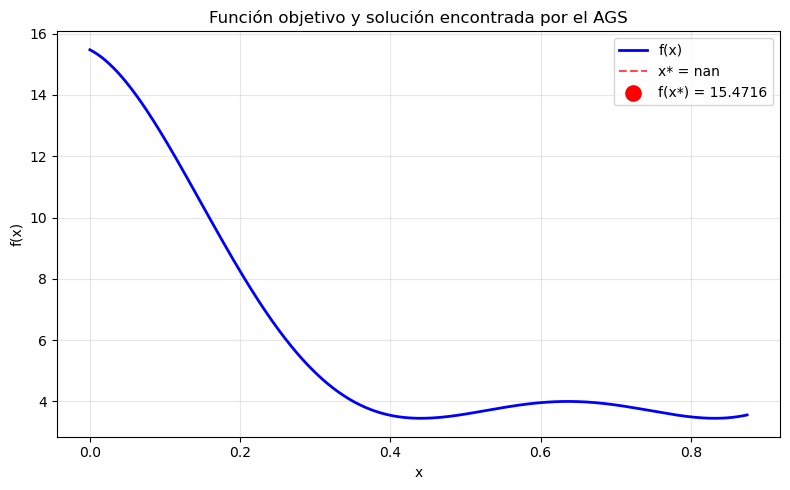

In [33]:
x_vals = np.linspace(0, 0.875, 500)
u_vals = (11.0 / 2.0) * x_vals - (7.0 / 2.0)
f_vals = 4 - u_vals ** 2 * np.cos(u_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, f_vals, 'b-', linewidth=2, label='f(x)')
plt.axvline(mejor_x, color='red', linestyle='--', alpha=0.7, label=f'x* = {mejor_x:.4f}')
plt.scatter([mejor_x], [mejor_val], color='red', zorder=5, s=120,
            label=f'f(x*) = {mejor_val:.4f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Función objetivo y solución encontrada por el AGS')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()